<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/SG_Stability_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
!pip install -q kaggle

In [4]:
import requests

url = "https://www.kaggle.com/api/v1/datasets/download/pcbreviglieri/smart-grid-stability"

r = requests.get(url)

print(r.status_code)
print(len(r.content))

200
6601512


In [5]:
with open("/content/smart_grid_stability.zip", "wb") as f:
    f.write(r.content)

print("Downloaded successfully!")

Downloaded successfully!


In [6]:
import zipfile

with zipfile.ZipFile("/content/smart_grid_stability.zip", "r") as zip_ref:
    zip_ref.extractall("/content/smart_grid")

print("Extracted!")


Extracted!


In [7]:
import os

os.listdir("/content/smart_grid")

['smart_grid_stability_augmented.csv']

In [8]:
import os

for file in os.listdir("/content/smart_grid"):
    print(file)

smart_grid_stability_augmented.csv


In [9]:
import pandas as pd

file_path = "/content/smart_grid/smart_grid_stability_augmented.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (60000, 14)


In [10]:
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [11]:
print(df.columns.tolist())

['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'stab', 'stabf']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    60000 non-null  float64
 1   tau2    60000 non-null  float64
 2   tau3    60000 non-null  float64
 3   tau4    60000 non-null  float64
 4   p1      60000 non-null  float64
 5   p2      60000 non-null  float64
 6   p3      60000 non-null  float64
 7   p4      60000 non-null  float64
 8   g1      60000 non-null  float64
 9   g2      60000 non-null  float64
 10  g3      60000 non-null  float64
 11  g4      60000 non-null  float64
 12  stab    60000 non-null  float64
 13  stabf   60000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 6.4+ MB


In [14]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nStability Labels:\n", df['stabf'].value_counts().sort_index())
print("\nNote: The 'stabf' column indicates stability (stable or unstable).")

Missing values per column:
 Series([], dtype: int64)

Stability Labels:
 stabf
stable      21720
unstable    38280
Name: count, dtype: int64

Note: The 'stabf' column indicates stability (stable or unstable).


In [16]:
# Handle missing values (no missing values found from previous checks, but keeping for robustness)
df.fillna(df.median(numeric_only=True), inplace=True)

# 'session_id' column does not exist, so skipping df.drop for it.
# Separate features (X) and target (y)
# 'stabf' is the target column, and 'stab' is highly correlated with 'stabf', so it should also be dropped from features.
X = df.drop(columns=['stabf', 'stab'])
y = df['stabf']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scale the features
X_scaled = StandardScaler().fit_transform(X)

# Convert X_scaled back to DataFrame to preserve column names for train_test_split
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=20, stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 48000 | Test: 12000


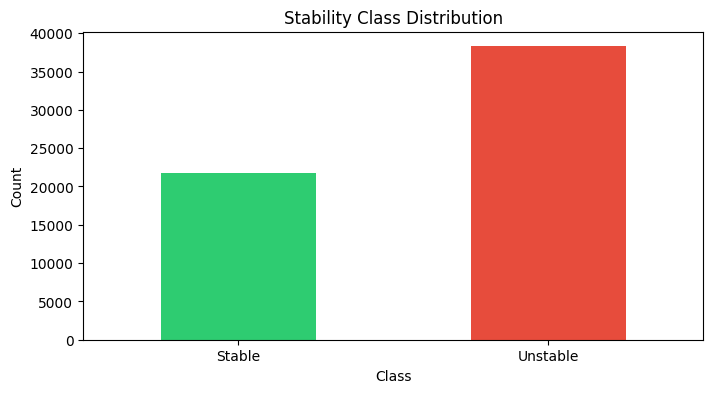

In [18]:
labels = ['Stable', 'Unstable'] # Updated to reflect 'stabf' categories

counts = df['stabf'].value_counts().sort_index() # Changed to 'stabf'

fig, ax = plt.subplots(figsize=(8, 4))

counts.plot.bar(
    ax=ax,
    color=['#2ecc71', '#e74c3c'] # Adjusted colors for two classes
)

ax.set_xticklabels(labels, rotation=0)
ax.set_title('Stability Class Distribution') # Updated title
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()

In [19]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.8958  Precision = 0.8958 Recall = 0.8958 F1=0.8958
KNN (k=5): Acc=0.8928  Precision = 0.8928 Recall = 0.8928 F1=0.8913
Logistic Reg: Acc=0.8157  Precision = 0.8134 Recall = 0.8157 F1=0.8136


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.7334     0.7263  0.7334    0.7246
5            0.7990     0.7961  0.7990    0.7950
10           0.8865     0.8859  0.8865    0.8860
15           0.8967     0.8967  0.8967    0.8967
20           0.8958     0.8958  0.8958    0.8958
None         0.8958     0.8958  0.8958    0.8958


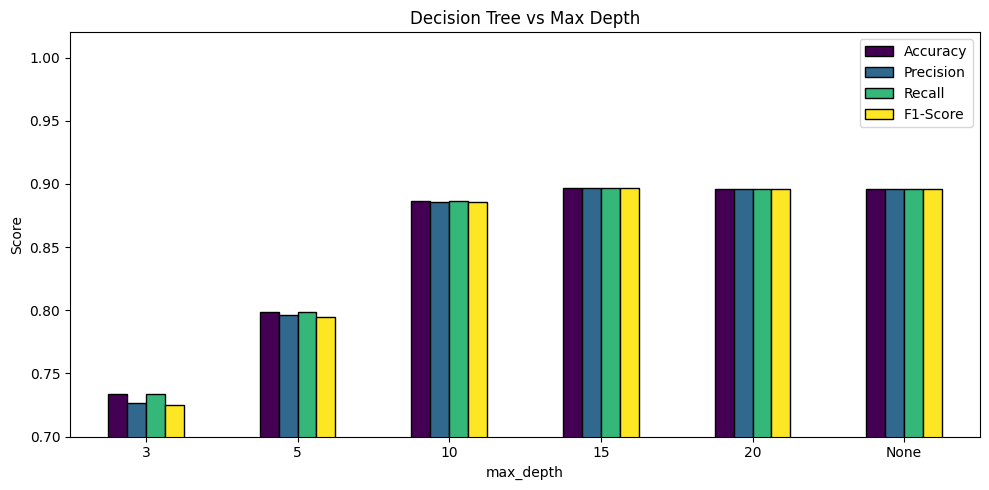

In [20]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [21]:
target_names = ['Benign', 'Attack'] # Changed to match the 2 classes (0 and 1) in attack_detected
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
              precision    recall  f1-score   support

      Benign     0.8559    0.8561    0.8560      4344
      Attack     0.9184    0.9182    0.9183      7656

    accuracy                         0.8958     12000
   macro avg     0.8871    0.8872    0.8872     12000
weighted avg     0.8958    0.8958    0.8958     12000


KNN (k=5)
              precision    recall  f1-score   support

      Benign     0.8945    0.7979    0.8434      4344
      Attack     0.8919    0.9466    0.9184      7656

    accuracy                         0.8928     12000
   macro avg     0.8932    0.8722    0.8809     12000
weighted avg     0.8928    0.8928    0.8913     12000


Logistic Reg
              precision    recall  f1-score   support

      Benign     0.7693    0.7010    0.7336      4344
      Attack     0.8385    0.8807    0.8591      7656

    accuracy                         0.8157     12000
   macro avg     0.8039    0.7909    0.7963     12000
weighted avg     0.8134    0.8157 

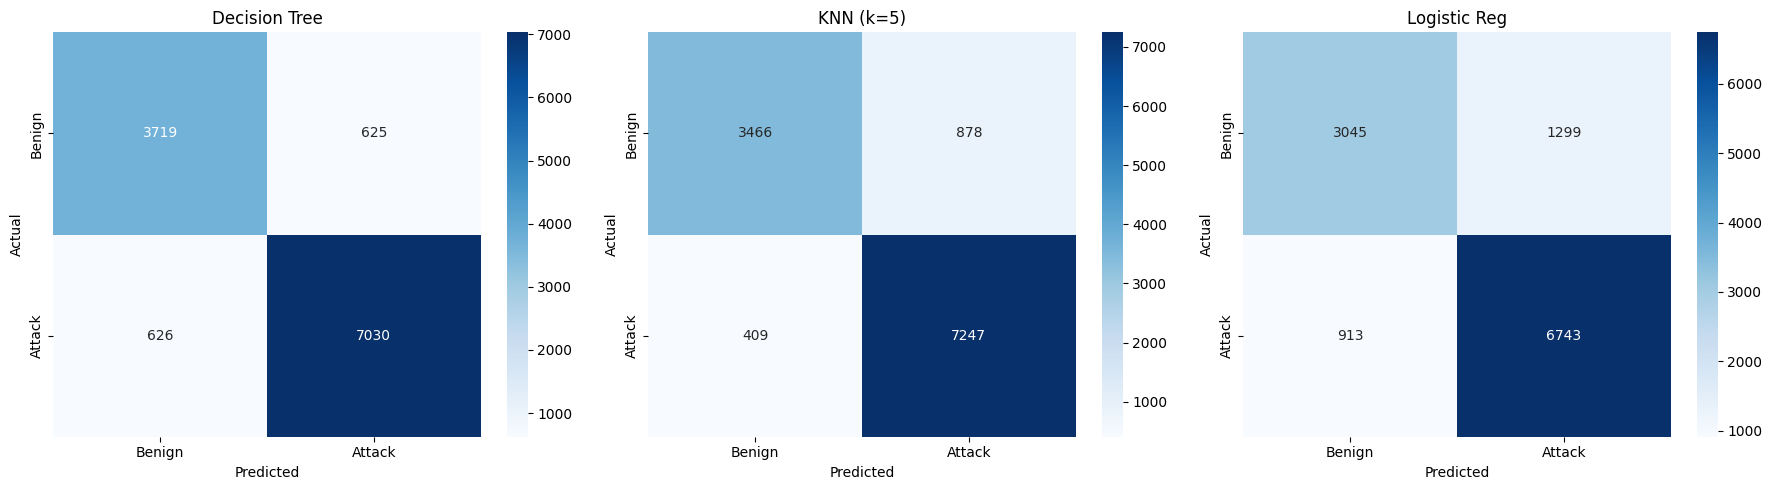

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

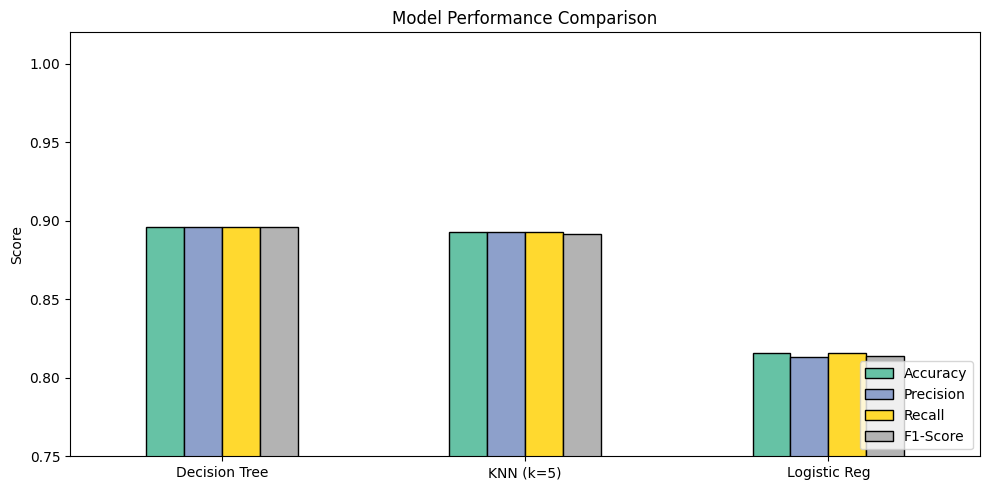


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8958     0.8958  0.8958    0.8958
KNN (k=5)        0.8928     0.8928  0.8928    0.8913
Logistic Reg     0.8157     0.8134  0.8157    0.8136


In [24]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))